# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Marvi Malik)_

**Roll Number:** _(023-24-0016)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [8]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")  # update path/filename if different


In [5]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [10]:
# Task 4 — dataset shape, column names, data types
# Dataset shape
print("Shape:", df.shape)
print("\nNumerical columns:", df.select_dtypes(include='number').columns.tolist())
print("\nCategorical columns:", df.select_dtypes(include='object').columns.tolist())


Shape: (7043, 21)

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [11]:
# Task 5 — identify identifier columns / wrong data types
print(df.dtypes)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [12]:
# Task 6 — unique values in 3 categorical columns
print(df['Contract'].unique())
print(df['InternetService'].unique())
print(df['PaymentMethod'].unique())


['Month-to-month' 'One year' 'Two year']
['DSL' 'Fiber optic' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Answer 1:**
_(Business_Problem: the telecom company is losing its customers to competitors that is known as CHURN, company wants to predict which customers want to leave early so they can take any action. For this target variable should be CHURN I think, which has two values "Yes" for those who are leaving and "No" for those who are not.)_

**Answer 2:**
_(% useful_Predictors:
1. tenure: how oold customer is, as old ones do not leave.
2. Monthly charges: more charges may result in more churn chances.
3. Contract: Those with month-to-month churn more.
4. InternetService: its performance tells the satisfaction of customers.
5. Tech_Support: due to lack of support customers leave.

Non_UseFull:
1. Customer_id: it's an identifier only not a predictor.
2. gender: nothing to do with churn.)_

**Answer 3:**
_(1. Do Senior Citozens churn more?
2. Do month-tomonth contractors churn more or less?)_

**Observations (Part 2):**
_(Task#4:
Dataset has 7043 rows and 21 columns. Only 3 numerical features. TotalCharges is missing from numerical — suspicious, it should be numerical!
Task#5:
Wrong data type: TotalCharges is stored as object string but should be float (numerical) since it represents monetary charges.
Task#6:
Contract has 3 categories (Month-to-month, One year, Two year) — all valid. InternetService has 3 categories — all valid. PaymentMethod has 4 categories — all valid. No unexpected or inconsistent categories found.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [13]:
# Task 7 — missing values: count and percentage per column
print(df.isnull().sum())
print("\nPercentage:")
print(df.isnull().mean()*100)


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Percentage:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: f

In [14]:
# check for TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [15]:
# Task 8 — duplicate rows vs duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())


Duplicate rows: 0
Duplicate customerIDs: 0


In [16]:
# Task 9 — investigate a suspicious / invalid value
print(df[df['TotalCharges'].isnull()])


      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

**Answer 7 (which missing-value problems need action, and why):**
_(No null values found initially, but TotalCharges had 11 hidden missing values stored as empty strings. These require action because TotalCharges is an important numerical feature. After converting to numeric, 11 NaN values appeared.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(No duplicate rows and no duplicate customer IDs found. These are different issues — duplicate rows mean exact same data repeated, while duplicate IDs would mean same customer recorded twice with different data. Both are 0 here.)_

**Answer 9 (suspicious value found and how):**
_(Found 11 rows where TotalCharges is NaN. All these customers have tenure = 0, meaning they just joined and have not been billed yet. This was discovered by converting TotalCharges to numeric which revealed hidden empty strings.)_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| _e.g. TotalCharges stored as text_ | _..._ | _..._ | _..._ |
| _TotalCharges stired as String_ | _convert to numerical value_ | _pd.to_numeric(errors='coerce')_ | _it represents money, should be float_ |
| _11 missing total charges_ | _fill with 0_ | _fillna(0)_ | _tenure=0 customers have no charges yet_ |

In [19]:
# Task 11 — apply your cleaning decisions here
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isnull().sum())


0
Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges dtype: float64

Dataset shape: (7043, 21)


In [20]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nTotalCharges dtype:", df['TotalCharges'].dtype)
print("\nDataset shape:", df.shape)


Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

TotalCharges dtype: float64

Dataset shape: (7043, 21)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

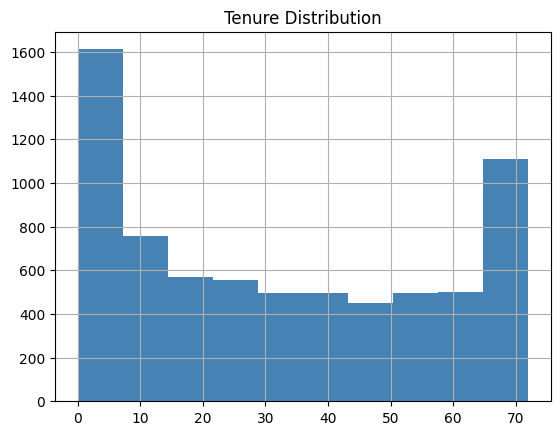

In [27]:
# Task 12 — numerical feature 1: distribution plot
df['tenure'].hist(color='steelblue')
plt.title('Tenure Distribution')
plt.show()


**Observation:** _(what did you learn from this chart?

Tenure is bimodal — many new customers (0) and long-term customers.)_

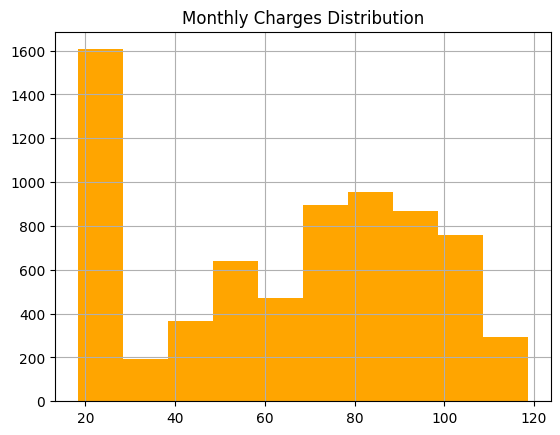

In [22]:
# Task 12 — numerical feature 2: distribution plot
# Already plotted above in combined chart
df['MonthlyCharges'].hist(color='orange')
plt.title('Monthly Charges Distribution')
plt.show()


**Observation:** _(what did you learn from this chart?

MonthlyCharges is right-skewed. Month-to-month contracts are most common. DSL and Fiber optic are most used internet services.)_

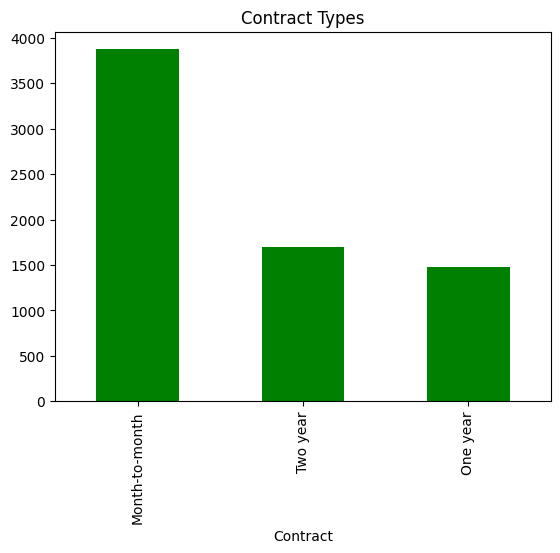

In [25]:
# Task 12 — categorical feature 1: distribution plot
df['Contract'].value_counts().plot(kind='bar', color='green')
plt.title('Contract Types')
plt.show()


**Observation:** _(what did you learn from this chart?

Month-to-month contracts are most common, followed by Two year and One year. This suggests many customers prefer flexibility over commitment.)_

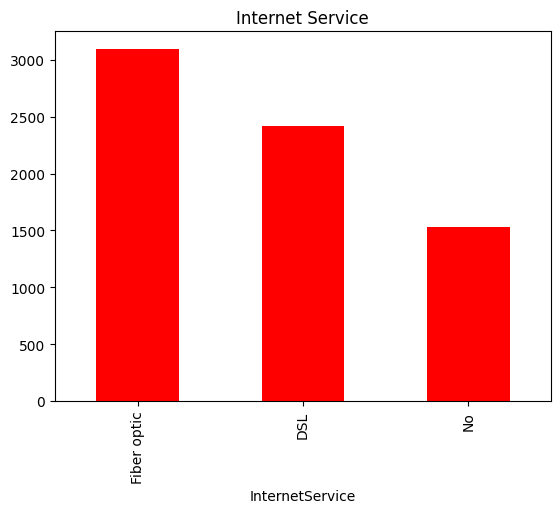

In [26]:
# Task 12 — categorical feature 2: distribution plot
df['InternetService'].value_counts().plot(kind='bar', color='red')
plt.title('Internet Service')
plt.show()


**Observation:** _(what did you learn from this chart?

DSL and Fiber optic are most used internet services. A significant number have no internet service at all.
)_

**Answer 13 (outliers / skew and possible explanation):**
_(MonthlyCharges shows a slight right skew — most customers pay lower amounts but some pay very high charges. TotalCharges is heavily right-skewed because new customers (tenure=0) have very low or zero total charges. Tenure shows a bimodal distribution — peaks at both ends (new and long-term customers). No extreme outliers found in any numerical feature.)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


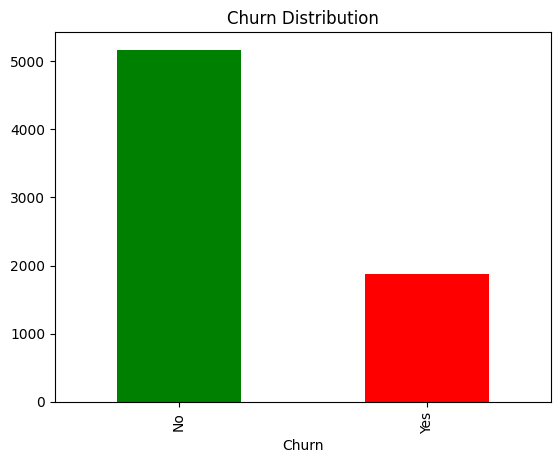

In [28]:
# Task 14 — churn counts and percentages
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True)*100)

df['Churn'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Churn Distribution')
plt.show()


**Answer 14 (balanced or imbalanced?):**
_(Imbalanced, Non-churn is more than churn.)_

**Answer 15 (why imbalance might matter later):**
_

(Class imbalance matters because a model can simply predict 'No churn' for every customer and still achieve 73% accuracy without actually learning to identify churners. This means the model will miss most actual churners — which is the whole point of building it. Evaluation metrics like accuracy become misleading with imbalanced data_)

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


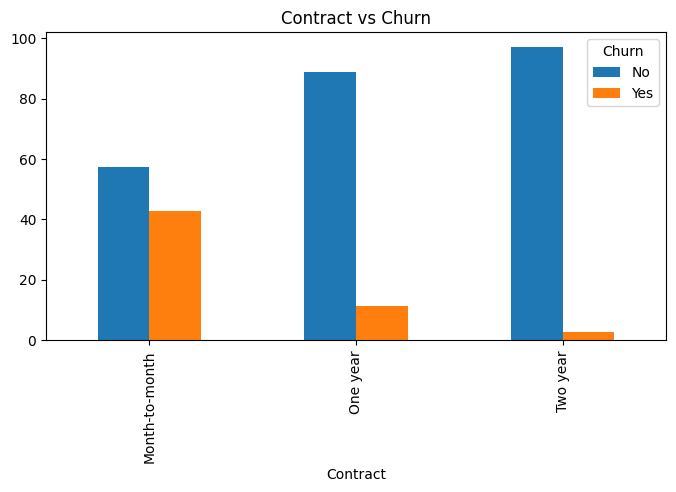

In [29]:
# Task 16 — categorical feature 1 vs Churn
# Contract vs Churn
ct1 = pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100
print(ct1)
ct1.plot(kind='bar', figsize=(8,4))
plt.title('Contract vs Churn')
plt.show()



**Observation:** _Month-to-month customers churn much more than long-term contract customers._

**Evidence:** _Month-to-month churn rate ~43%, Two-year only ~3%._

**Possible Explanation:** _term contracts create commitment, making it harder to leave._

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


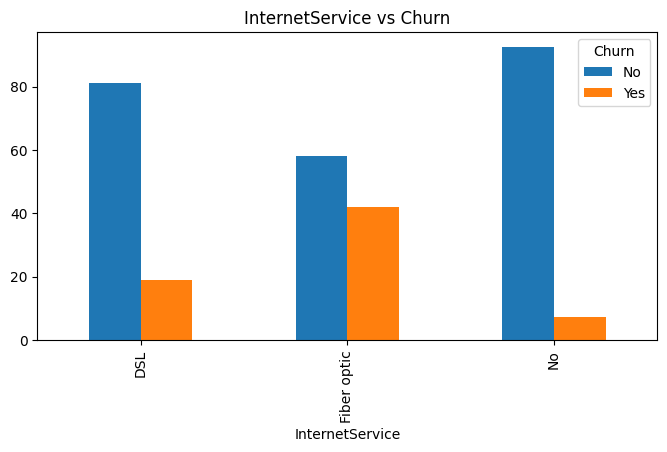

In [30]:
# Task 16 — categorical feature 2 vs Churn
# InternetService vs Churn
ct2 = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100
print(ct2)
ct2.plot(kind='bar', figsize=(8,4))
plt.title('InternetService vs Churn')
plt.show()



**Observation:** _Month-to-month customers churn much more than long-term contract customers._

**Evidence:** _Fiber optic churn ~42%, DSL ~19%, No internet ~7%._

**Possible Explanation:** _Fiber optic is expensive, customers may find cheaper alternatives._

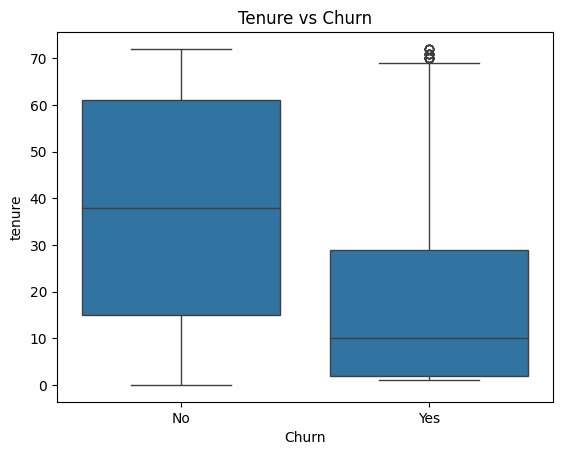

In [34]:
# Task 17 — numerical feature 1 vs Churn
# Feature 1 — Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()


**Observation:** _Churned customers have lower tenure_

**Evidence:** _Median tenure for churned ~10 months, non-churned ~38 months._

**Possible Explanation:** _New customers haven't built loyalty yet and leave early._

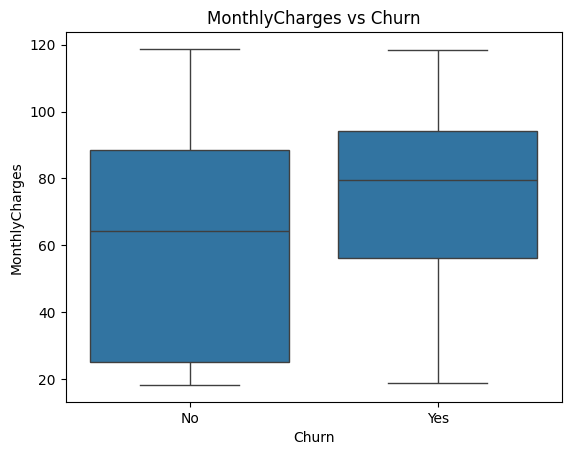

In [35]:
# Task 17 — numerical feature 2 vs Churn
# Feature 2 — MonthlyCharges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges vs Churn')
plt.show()

**Observation:** _Churned customers pay higher monthly charges._

**Evidence:** _Churned median ~$79, Non-churned median ~$61._

**Possible Explanation:** _Higher bills frustrate customers, pushing them to competitors._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

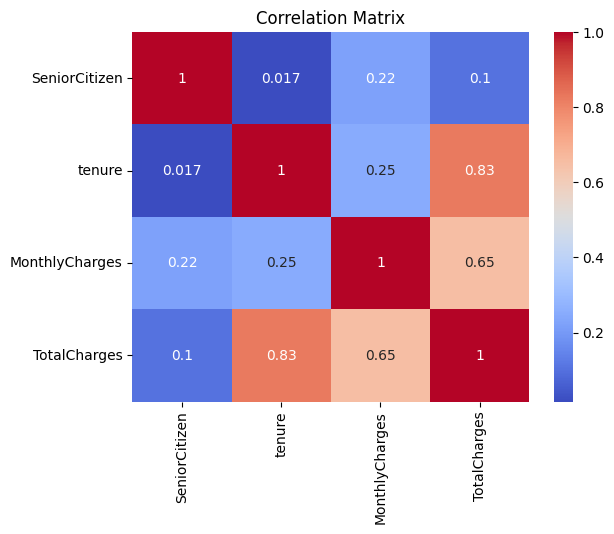

In [36]:
# Task 18 — correlation matrix and heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


**Answer 18 (most correlated pairs):**


_(tenure and TotalCharges are strongly correlated (0.83). MonthlyCharges and TotalCharges also correlated (0.65). This makes sense — longer tenure = higher total charges.)_

**Answer 19 (correlation vs. causation; potential problems):**


_(Correlation does not imply causation. High tenure causes high TotalCharges mathematically — it's a derived relationship. Having both tenure and TotalCharges in a model could cause multicollinearity problems, making it harder for the model to distinguish their individual effects on churn.)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**


_(customerID is purely an identifier — it should be removed as it has no predictive value. TotalCharges could be a data leakage risk since it depends on tenure which is already in the dataset.)_

**Answer 21 (what would go wrong):**

_(If customerID were left in the model, it would memorize individual customers rather than learning patterns. This would cause overfitting — perfect training accuracy but terrible performance on new customers. The model would learn nothing useful.)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | No predictive value |
| tenure | Numerical | Feature | keep | Strong predictor |
| Contract | Categorical | Feature | keep |Strong Predictor  |
| Churn | Categorical | Target | Keep |This is what we predict. |
| Total Charges | numerical | Feature| keep | Usage History |
|TechSupport | categorical | Feature| keep | Service Factor |
| StreaminTv| Categorical| Feature| keep| Service Usage|
|gender|	Categorical|	Feature|	Keep|	May affect churn|
|SeniorCitizen|	Numerical|	Feature	|Keep|	Age factor|
|Partner	|Categorical	|Feature	|Keep	|Lifestyle |factor|
|Dependents	|Categorical	|Feature	|Keep	|Lifestyle| factor|
|PhoneService	|Categorical|	Feature||	Keep	|Service usage|
|MultipleLines|	Categorical	|Feature|	Keep|	Service usage|
|InternetService	|Categorical	|Feature|	Keep|	Strong predictor|
|OnlineSecurity	|Categorical|	Feature	|Keep|	Service factor|
|OnlineBackup	|Categorical	|Feature|	Keep	|Service factor|
|DeviceProtection|	Categorical|	Feature|	Keep|	Service factor|
|StreamingMovies	|Categorical|	Feature	|Keep	|Service usage|
|PaperlessBilling	|Categorical|	Feature	|Keep	|Billing preference|
|PaymentMethod	|Categorical	|Feature	|Keep	|Payment| behavior|
|MonthlyCharges|	Numerical	|Feature|	Keep	|Strong predictor|


_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [39]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()


# ... apply your cleaning steps here ...
clean_df = clean_df.drop(columns=['customerID'])
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)
# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved...")


Saved...


In [44]:
pd.read_csv("clean_churn.csv").head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print(clean_df.info())
print("\nMissing values:", clean_df.isnull().sum().sum())
print("Duplicates:", clean_df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _Month-to-month customers churn most_
- Evidence: _43% churn rate vs 3% for two-year contracts_
- Interpretation: _Contract length is the strongest churn predictor_

**Finding 2**
- Observation: Churned customers have lower tenure
- Evidence: Median tenure churned=10 months, non-churned=38 months
- Interpretation: Early months are critical for customer retention

**Finding 3**
- Observation: Fiber optic customers churn more
- Evidence: ~42% churn rate vs 19% DSL
- Interpretation: High cost of fiber optic drives customers away

**Finding 4**
- Observation: Higher monthly charges = more churn
- Evidence: Churned median $79 vs non-churned $61
- Interpretation: Price sensitivity is a major churn factor

**Finding 5**
- Observation: Dataset is imbalanced
- Evidence: 73% No churn, 27% Yes churn
- Interpretation: Model evaluation must use metrics beyond accuracy

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?

   _(TotalCharges stored as string with 11 hidden missing values for new customers (tenure=0))_
2. What was the most interesting pattern you discovered?

   _(Month-to-month contract customers churn at 43% — almost half leave!)_
3. Which feature seems most useful for predicting churn?

   _(Contract type — strongest predictor of churn)_
4. Which feature should probably not be used, and why?

   _(customerID — purely identifier, no predictive value, causes overfitting)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?

   _(Encode categorical variables (One-hot encoding), normalize numerical features (MinMaxScaler), handle class imbalance (SMOTE or class weights))_
6. What would you do next if you had another 3 hours?

   _(Explore more feature combinations, try feature engineering (e.g. charges per month of tenure), and investigate why fiber optic customers churn more)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook